Fetching Student Dropout dataset from UCI...

Class Distribution:
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
dtype: float64

Optimizing Multinomial Logit Model...
Best Regularization Strength (C): 1

Running 5-Fold Cross-Validation...
LDA Mean CV Accuracy: 0.7584 (+/- 0.0132)
Logit Mean CV Accuracy: 0.7652 (+/- 0.0174)

COMPUTATIONAL EFFICIENCY
Logit Training Time: 0.055139s
LDA Training Time:   0.012537s

STATISTICAL PERFORMANCE

Multinomial Logit Model:
               precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885


Linear Discriminant Analysis:
               precision    recall  f1-score   support

     Dropout       0.88      0.69      0.77       2

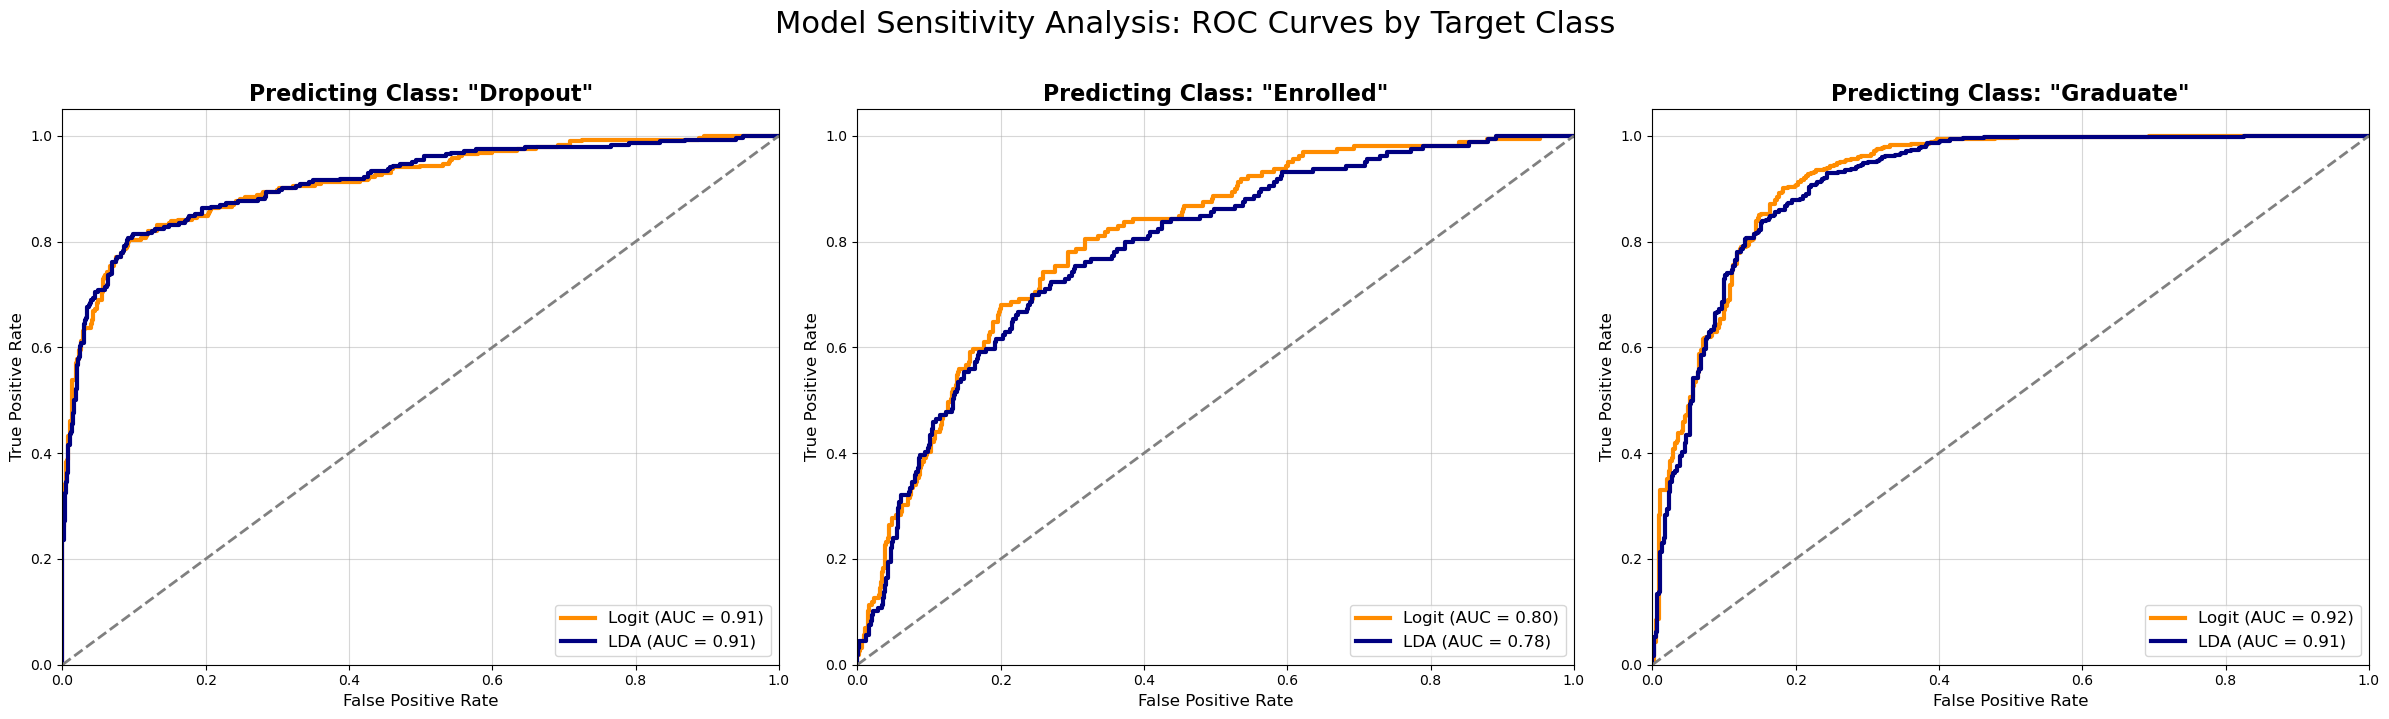

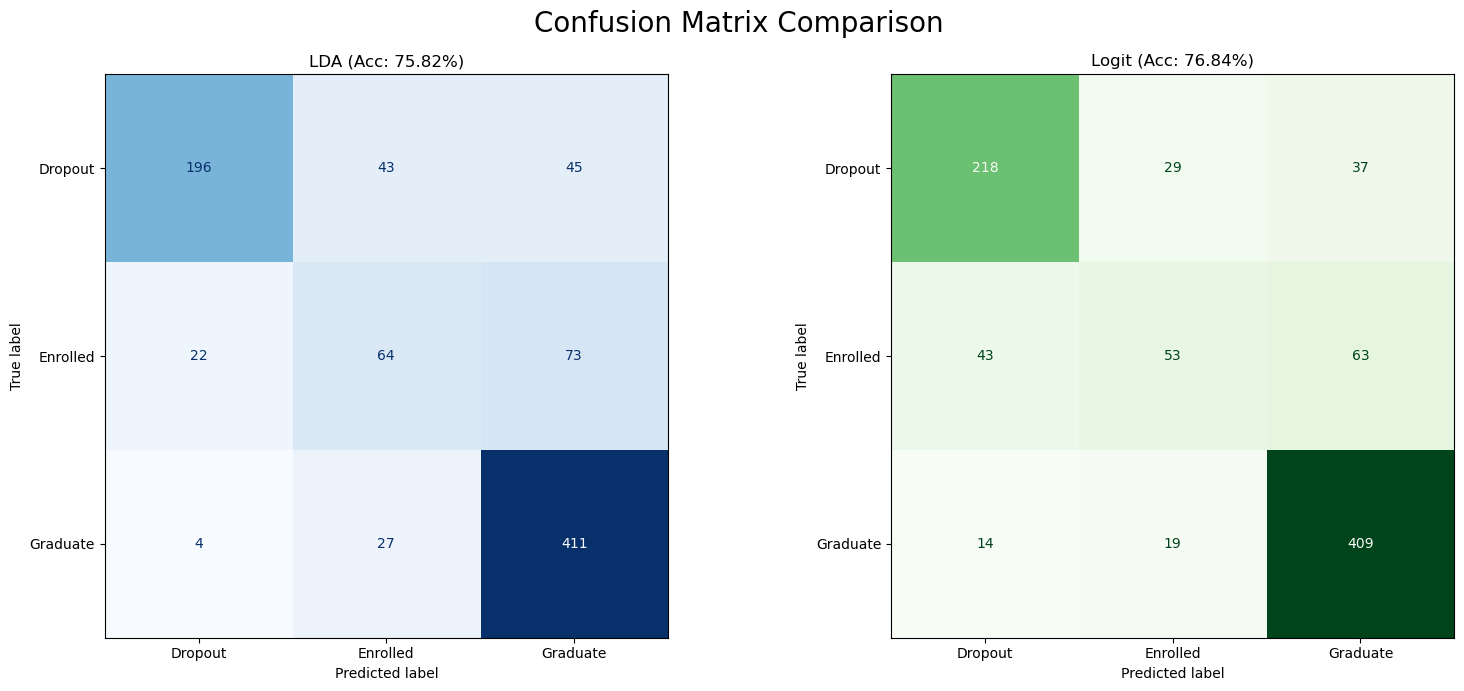

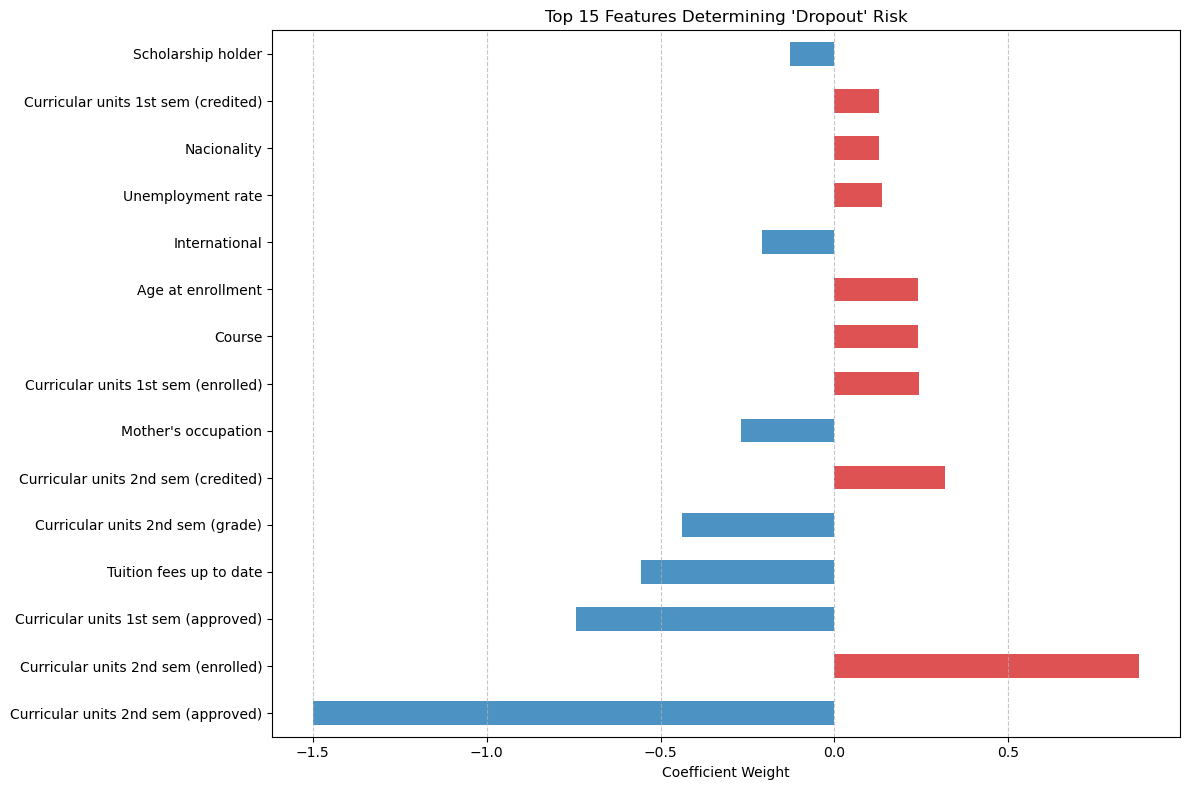

Generating Decision Boundary Plots...


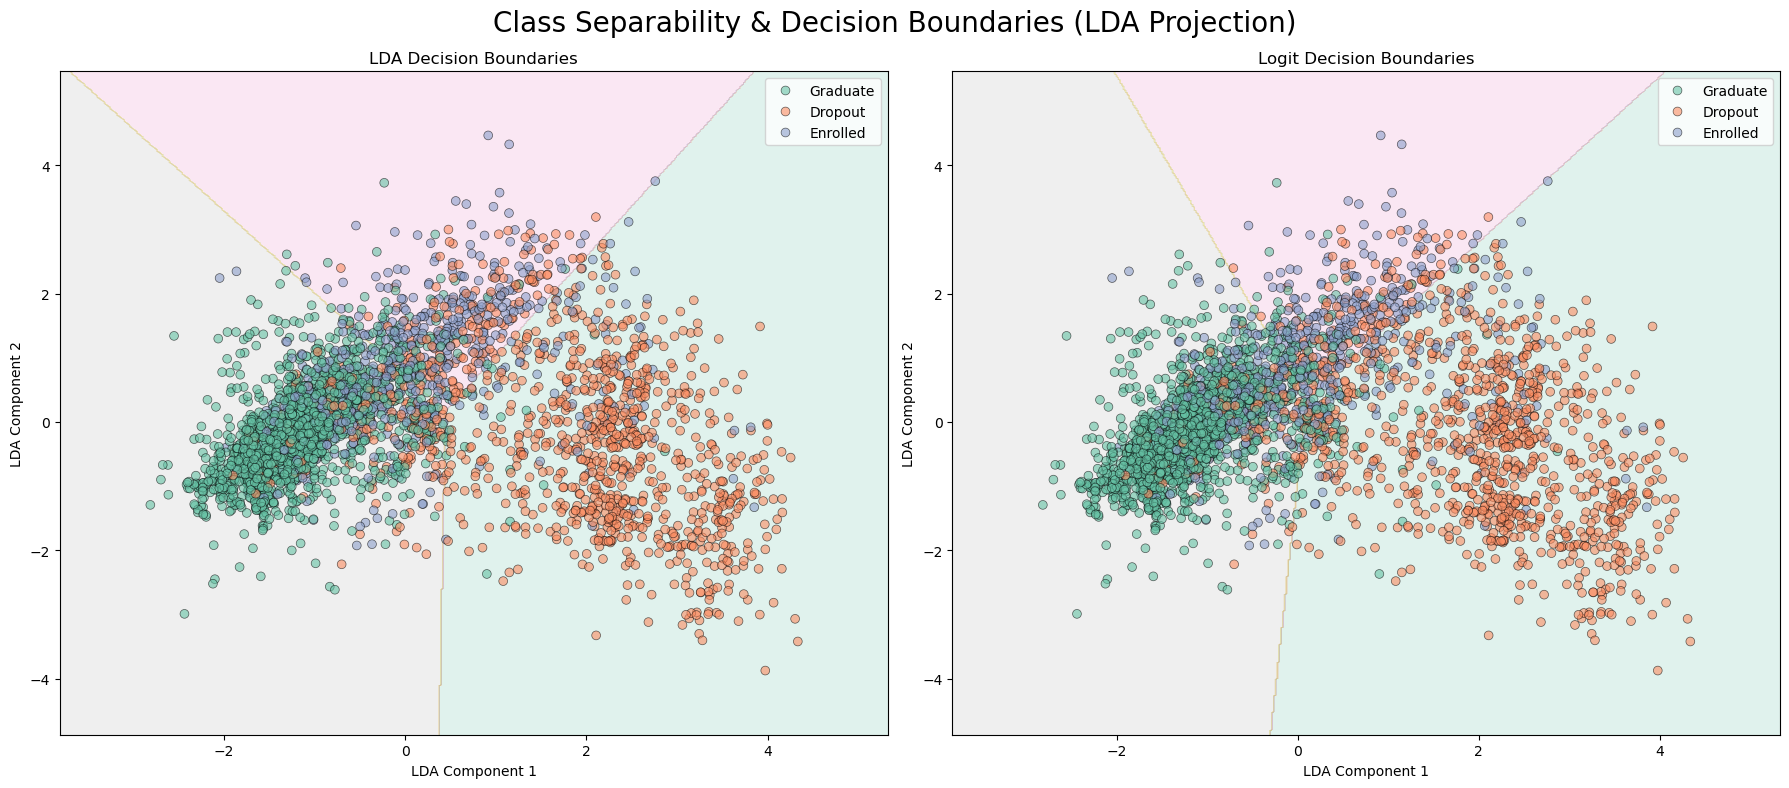

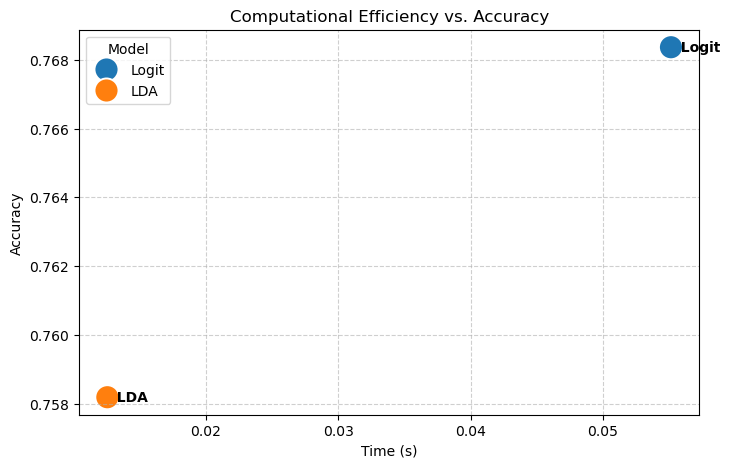

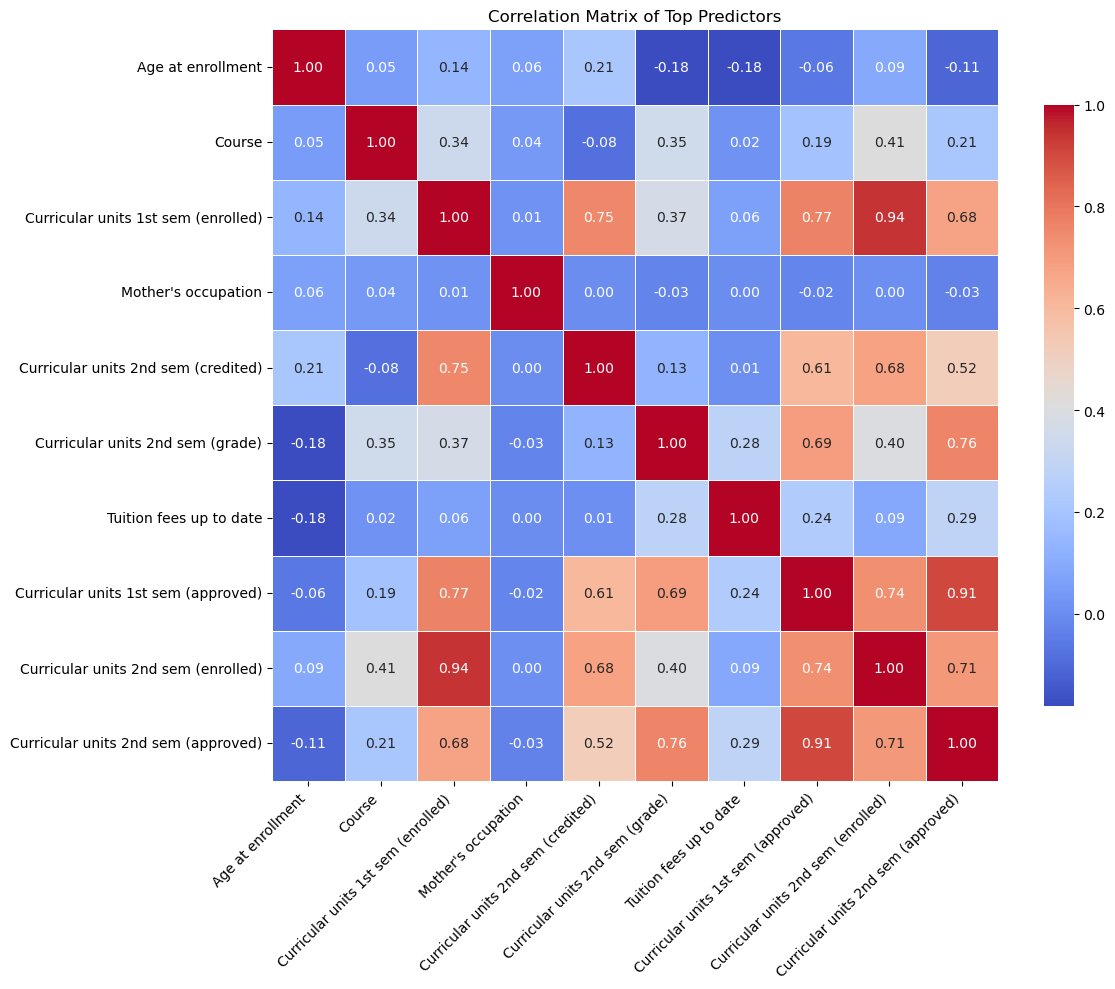

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler , label_binarize
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    log_loss,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc
)

# 1. DATA ACQUISITION & ROBUST PREPROCESSING
print("Fetching Student Dropout dataset from UCI...")
dataset = fetch_ucirepo(id=697) 
X = dataset.data.features
y = dataset.data.targets.values.ravel()

print("\nClass Distribution:")
print(pd.Series(y).value_counts(normalize=True))

# Even if the current dataset is clean, this prevents future errors
if X.isnull().values.any():
    print("Missing values detected. Imputing with median...")
    X = X.fillna(X.median())

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize Features: Mandatory for PCA and consistent coefficients
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. HYPERPARAMETER TUNING
print("\nOptimizing Multinomial Logit Model...")
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000), 
    param_grid, 
    cv=5
)

grid_search.fit(X_train_scaled, y_train)
best_logit = grid_search.best_estimator_
print(f"Best Regularization Strength (C): {grid_search.best_params_['C']}")

# 3. STATISTICAL RIGOR: CROSS-VALIDATION (NEW)
print("\nRunning 5-Fold Cross-Validation...")
lda = LinearDiscriminantAnalysis()
lda_cv_scores = cross_val_score(lda, X_train_scaled, y_train, cv=5)
logit_cv_scores = cross_val_score(best_logit, X_train_scaled, y_train, cv=5)

print(f"LDA Mean CV Accuracy: {lda_cv_scores.mean():.4f} (+/- {lda_cv_scores.std()*2:.4f})")
print(f"Logit Mean CV Accuracy: {logit_cv_scores.mean():.4f} (+/- {logit_cv_scores.std()*2:.4f})")


# 4. MODEL TRAINING & COMPUTATIONAL EFFICIENCY
print("\n" + "="*30)
print("COMPUTATIONAL EFFICIENCY")
print("="*30)

# Multinomial Logistic Regression (MLR) — Use tuned model
start_logit = time.perf_counter()
logit = best_logit  # Use GridSearch best model
logit.fit(X_train_scaled, y_train)
logit_time = time.perf_counter() - start_logit

# Linear Discriminant Analysis (LDA)
start_lda = time.perf_counter()
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
lda_time = time.perf_counter() - start_lda

print(f"Logit Training Time: {logit_time:.6f}s")
print(f"LDA Training Time:   {lda_time:.6f}s")

# 5. STATISTICAL EVALUATION
print("\n" + "="*30)
print("STATISTICAL PERFORMANCE")
print("="*30)

y_pred_logit = logit.predict(X_test_scaled)
y_pred_lda = lda.predict(X_test_scaled)

print("\nMultinomial Logit Model:\n", classification_report(y_test, y_pred_logit))
print("\nLinear Discriminant Analysis:\n", classification_report(y_test, y_pred_lda))

# Log-Loss (Measures confidence quality)
logit_probs = logit.predict_proba(X_test_scaled)
lda_probs = lda.predict_proba(X_test_scaled)
print(f"Logit Log-Loss: {log_loss(y_test, logit_probs):.4f}")
print(f"LDA Log-Loss:   {log_loss(y_test, lda_probs):.4f}")

# ROC-AUC Score
roc_logit = roc_auc_score(y_test, logit_probs, multi_class='ovr')
roc_lda = roc_auc_score(y_test, lda_probs, multi_class='ovr')

print(f"Logit ROC-AUC: {roc_logit:.4f}")
print(f"LDA ROC-AUC:   {roc_lda:.4f}")

# 6.VISUALIZATION: ROC CURVES FOR ALL 3 CLASSES
# Binarize the labels for multi-class ROC
logit_acc = accuracy_score(y_test, y_pred_logit)
lda_acc = accuracy_score(y_test, y_pred_lda)

classes = logit.classes_
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes)

# Get probabilities
y_score_logit = logit.predict_proba(X_test_scaled)
y_score_lda = lda.predict_proba(X_test_scaled)

# Create a figure with 3 subplots (one for each class)
fig, axes = plt.subplots(1, n_classes, figsize=(24, 7))

# Loop through each class and plot
for i in range(n_classes):
    class_label = classes[i]
    
    # Calculate Logit ROC/AUC
    fpr_logit, tpr_logit, _ = roc_curve(y_test_bin[:, i], y_score_logit[:, i])
    roc_auc_logit = auc(fpr_logit, tpr_logit)
    
    # Calculate LDA ROC/AUC
    fpr_lda, tpr_lda, _ = roc_curve(y_test_bin[:, i], y_score_lda[:, i])
    roc_auc_lda = auc(fpr_lda, tpr_lda)
    
    # Plotting
    ax = axes[i]
    ax.plot(fpr_logit, tpr_logit, color='darkorange', lw=3, label=f'Logit (AUC = {roc_auc_logit:.2f})')
    ax.plot(fpr_lda, tpr_lda, color='navy', lw=3, label=f'LDA (AUC = {roc_auc_lda:.2f})')
    
    # Diagonal line (random guess)
    ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    
    # Formatting
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'Predicting Class: "{class_label}"', fontsize=16, fontweight='bold')
    ax.legend(loc="lower right", fontsize=12)
    ax.grid(True, alpha=0.5)

plt.suptitle("Model Sensitivity Analysis: ROC Curves by Target Class", fontsize=22, y=1.02)
plt.tight_layout()
plt.show()

# 7. VISUALIZATION: CONFUSION MATRICES
fig, ax = plt.subplots(1, 2, figsize=(16, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lda, ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title(f"LDA (Acc: {lda_acc:.2%})")
ax[0].grid(False) 

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logit, ax=ax[1], cmap='Greens', colorbar=False)
ax[1].set_title(f"Logit (Acc: {logit_acc:.2%})")
ax[1].grid(False)

plt.suptitle("Confusion Matrix Comparison", fontsize=20)
plt.tight_layout()
plt.show()


# 8. FEATURE IMPORTANCE (Predicting Dropout)
dropout_idx = None

try:
    dropout_idx = np.where(logit.classes_ == 'Dropout')[0][0]
    importance = pd.Series(logit.coef_[dropout_idx], index=X.columns)

    plt.figure(figsize=(12, 8))
    top_features = importance.abs().nlargest(15)
    real_values = importance[top_features.index]
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in real_values]

    real_values.plot(kind='barh', color=colors, alpha=0.8)
    plt.title("Top 15 Features Determining 'Dropout' Risk")
    plt.xlabel("Coefficient Weight")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except IndexError:
    print("Class 'Dropout' not found.")


# 9. IMPROVED VISUALIZATION: LDA-BASED DIMENSIONALITY REDUCTION
print("Generating Decision Boundary Plots...")
lda_transformer = LinearDiscriminantAnalysis(n_components=2)
X_train_lda_proj = lda_transformer.fit_transform(X_train_scaled, y_train)

# Train simple models on the 2D data for visualization only
lda_2d = LinearDiscriminantAnalysis().fit(X_train_lda_proj, y_train)
logit_2d = LogisticRegression(solver='lbfgs').fit(X_train_lda_proj, y_train)

def plot_boundary(model, X, y, title, ax):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    unique_labels = np.unique(y)
    label_map = {label: i for i, label in enumerate(unique_labels)}
    Z_int = np.array([label_map[z] for z in Z]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z_int, alpha=0.2, cmap='Set2')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set2', edgecolor='k', s=40, ax=ax, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("LDA Component 1")
    ax.set_ylabel("LDA Component 2")

fig, ax = plt.subplots(1, 2, figsize=(18, 8))
plot_boundary(lda_2d, X_train_lda_proj, y_train, "LDA Decision Boundaries", ax[0])
plot_boundary(logit_2d, X_train_lda_proj, y_train, "Logit Decision Boundaries", ax[1])
plt.suptitle("Class Separability & Decision Boundaries (LDA Projection)", fontsize=20)
plt.tight_layout()
plt.show()

# 10. EFFICIENCY VS ACCURACY
acc_logit = accuracy_score(y_test, y_pred_logit)
acc_lda = accuracy_score(y_test, y_pred_lda)

results_df = pd.DataFrame({
    'Model': ['Logit', 'LDA'],
    'Accuracy': [acc_logit, acc_lda],
    'Time (s)': [logit_time, lda_time]
})

plt.figure(figsize=(8, 5))
sns.scatterplot(data=results_df, x='Time (s)', y='Accuracy', hue='Model', s=300)
for i in range(results_df.shape[0]):
    plt.text(results_df.iloc[i]['Time (s)'], results_df.iloc[i]['Accuracy'], 
             f"  {results_df.iloc[i]['Model']}", verticalalignment='center', fontweight='bold')
plt.title("Computational Efficiency vs. Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 11. DATA INSIGHTS: CORRELATION HEATMAP
if dropout_idx is not None:

    top_10_indices = np.argsort(np.abs(logit.coef_[dropout_idx]))[-10:]
    top_10_features = X.columns[top_10_indices]

    plt.figure(figsize=(12, 10))
    corr_matrix = X_train[top_10_features].corr()

    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        fmt=".2f",
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title("Correlation Matrix of Top Predictors")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
